<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/LogReturns-vs-Returns-and-Rolling-Statistics/LogReturns_vs_Returns_and_Rolling_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm

import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
tickers = ['AAPL']

data = yf.download(tickers, start = '2025-01-01', end = '2026-01-01')['Close']
data.head()

/tmp/ipython-input-1047122637.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = '2025-01-01', end = '2026-01-01')['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,AAPL
Date,
2025-01-02,242.752106
2025-01-03,242.264313
2025-01-06,243.896912
2025-01-07,241.119492
2025-01-08,241.607269


In [ ]:
data['log_returns'] = np.log(data['AAPL']/data['AAPL'].shift(1))
data['returns'] = data['AAPL'].pct_change()
data = data.dropna()
data.head()

Ticker,AAPL,log_returns,returns
Date,,,
2025-01-03,242.264313,-0.002011,-0.002009
2025-01-06,243.896912,0.006716,0.006739
2025-01-07,241.119492,-0.011453,-0.011388
2025-01-08,241.607269,0.002021,0.002023
2025-01-10,235.783630,-0.024399,-0.024104


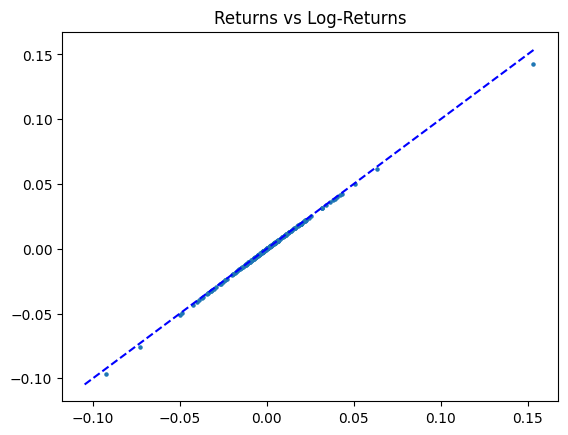

In [ ]:
f, ax = plt.subplots()
plt.title('Returns vs Log-Returns')
ax.scatter(data['returns'], data['log_returns'], s = 5)

# Get current axis limits
xlims = ax.get_xlim()
ylims = ax.get_ylim()

# Determine the min/max for the diagonal line
# Use max of lower limits and min of upper limits to ensure the line stays within the current view
low = max(xlims[0], ylims[0])
high = min(xlims[1], ylims[1])

# Plot the line
ax.plot([low, high], [low, high], color='blue', linestyle='--')
plt.show()

Perfectly on the line in the middle of the graph, but deviates from the lines slightly at the edges

In [ ]:
year_returns_sum = data['returns'].sum()
year_log_returns_sum = data['log_returns'].sum()
total_return = (data['AAPL'].iloc[-1] - data['AAPL'].iloc[0])/data['AAPL'].iloc[0]
year_returns_sum, year_log_returns_sum, total_return

(np.float64(0.16446746337930807),
 np.float64(0.1132463924815689),
 np.float64(0.12216274147929644))

Volatility Drag

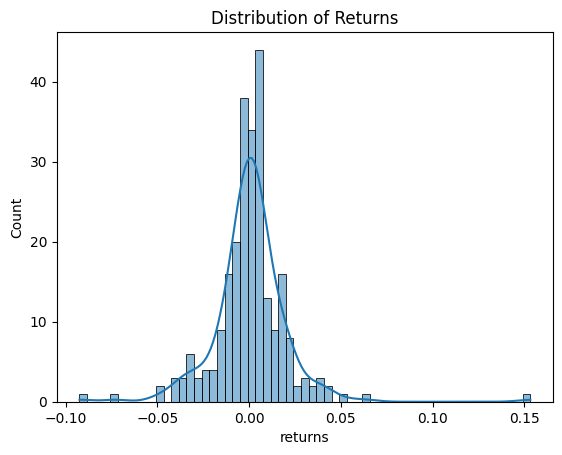

In [ ]:
plt.title("Distribution of Returns")
sns.histplot(data['returns'], kde = True)

plt.show()

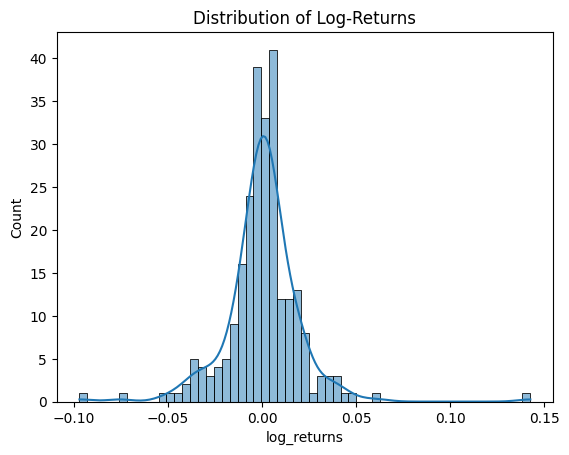

In [ ]:
plt.title("Distribution of Log-Returns")
sns.histplot(data['log_returns'], kde = True)

plt.show()

In [ ]:
tickers = ['AAPL']

data = yf.download(tickers, start = '2025-01-01', end = '2026-01-01')['Close']

returns = data.pct_change().dropna()
returns

/tmp/ipython-input-2799196174.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = '2025-01-01', end = '2026-01-01')['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,AAPL
Date,
2025-01-03,-0.002009
2025-01-06,0.006739
2025-01-07,-0.011388
2025-01-08,0.002023
2025-01-10,-0.024104
...,...
2025-12-24,0.005324
2025-12-26,-0.001497
2025-12-29,0.001317


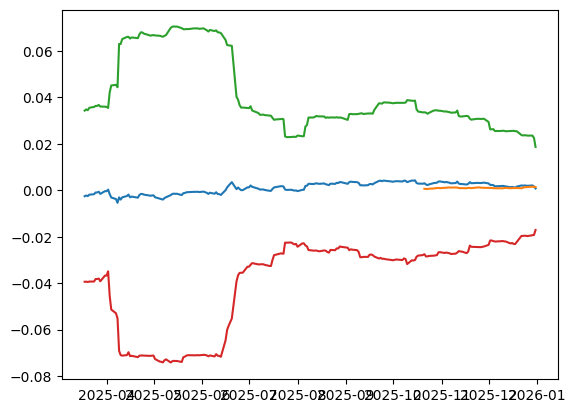

In [ ]:
window = 50
rolling_mean_50 = returns.rolling(50).mean()
rolling_mean_200 = returns.rolling(200).mean()

std50 = returns.rolling(50).std()
upper = rolling_mean_50 + (2*std50)
lower = rolling_mean_50 - (2*std50)

plt.plot(rolling_mean_50.index, rolling_mean_50.values)
plt.plot(rolling_mean_200.index, rolling_mean_200.values)
plt.plot(upper)
plt.plot(lower)
plt.show()

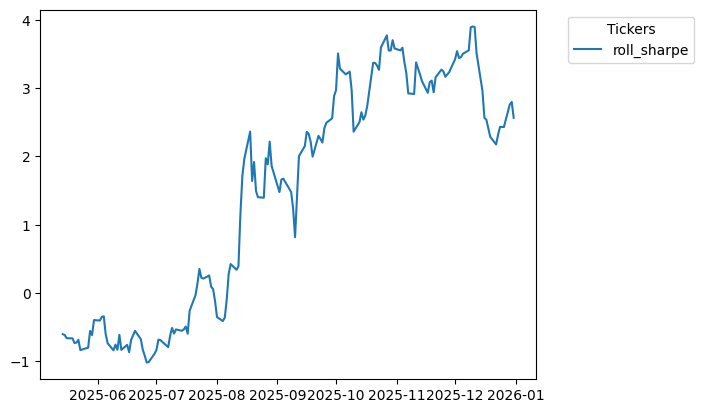

In [ ]:
roll_mean = returns.rolling(window=90).mean()
roll_vol = returns.rolling(window=90).std()
rolling_sharpe = (roll_mean * 252) / (roll_vol * np.sqrt(252))

plt.plot(rolling_sharpe, label = 'roll_sharpe')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Tickers")
plt.show()

Sharpe is constantly above 0 for majority of the year